In [111]:
import os
import torch
import torchvision
import xml.etree.ElementTree as ET
from PIL import Image
from torch.utils.data import DataLoader
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

In [112]:
class VOCDataset(torch.utils.data.Dataset):
    def __init__(self, root):
        self.img_dir = os.path.join(root, "JPEGImages")
        self.ann_dir = os.path.join(root, "Annotations")

        self.images = [f for f in os.listdir(self.img_dir) if f.endswith(".jpg")]

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path = os.path.join(self.img_dir, img_name)
        ann_path = os.path.join(self.ann_dir, img_name.replace(".jpg", ".xml"))

        try:
          img = Image.open(img_path).convert("RGB")
        except:
          return None

        boxes = []
        labels = []

        tree = ET.parse(ann_path)
        root = tree.getroot()

        for obj in root.findall("object"):
            bbox = obj.find("bndbox")

            xmin = int(bbox.find("xmin").text)
            ymin = int(bbox.find("ymin").text)
            xmax = int(bbox.find("xmax").text)
            ymax = int(bbox.find("ymax").text)

            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(1)

        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)

        return img, {"boxes": boxes, "labels": labels}

    def __len__(self):
        return len(self.images)

In [113]:
!wget http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar
!wget http://host.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar

--2026-04-16 06:57:47--  http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar
Resolving host.robots.ox.ac.uk (host.robots.ox.ac.uk)... 129.67.94.50
Connecting to host.robots.ox.ac.uk (host.robots.ox.ac.uk)|129.67.94.50|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.robots.ox.ac.uk/~vgg/projects/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar [following]
--2026-04-16 06:57:48--  https://www.robots.ox.ac.uk/~vgg/projects/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar [following]
--2026-04-16 06:57:49--  https://thor.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar
Resolving thor.robots.ox.ac.uk (thor.ro

In [114]:
!tar -xf VOCtrainval_06-Nov-2007.tar
!tar -xf VOCtrainval_11-May-2012.tar

tar: Unexpected EOF in archive
tar: rmtlseek not stopped at a record boundary
tar: Error is not recoverable: exiting now


In [115]:
import os

print(os.listdir("/content/VOCdevkit"))

['VOC2012', 'VOC2007']


In [116]:
train_dataset = VOCDataset("/content/VOCdevkit/VOC2012/")
test_dataset  = VOCDataset("/content/VOCdevkit/VOC2007/")

In [117]:
import os

print("VOC folders:", os.listdir("/content/VOCdevkit"))
print("VOC2012 check:", os.listdir("/content/VOCdevkit/VOC2012")[:5])

VOC folders: ['VOC2012', 'VOC2007']
VOC2012 check: ['JPEGImages', 'Annotations', 'ImageSets']


In [118]:
from torch.utils.data import DataLoader

def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=collate_fn
)

In [119]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def get_model():
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, 2)

    return model

In [120]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = get_model().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.005)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [121]:
import torchvision.transforms as T

transform = T.ToTensor()

model.train()

for epoch in range(1):   # ONLY 1 EPOCH
    total_loss = 0

    for i, (images, targets) in enumerate(train_loader):

        # limit steps (VERY IMPORTANT for speed)
        if i == 50:   # only 50 batches
            break

        images = [transform(img).to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print("Epoch:", epoch+1, "Loss:", total_loss)

Epoch: 1 Loss: 27.266172036528587


In [122]:
model.eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [123]:
import torchvision.transforms as T

transform = T.ToTensor()

for images, targets in test_loader:
    images = [transform(img).to(device) for img in images]

    with torch.no_grad():
        outputs = model(images)

    print(outputs)
    break

[{'boxes': tensor([[176.6752, 131.0998, 196.6527, 156.9079],
        [  0.0000,  79.4687, 332.3358, 329.5705],
        [168.7955,  75.7722, 335.0219, 313.9669],
        [179.9484, 131.6026, 190.5244, 152.3694],
        [168.5261, 138.4072, 197.5838, 154.3292],
        [177.9234, 136.3802, 200.4980, 149.7505],
        [186.5655, 136.2023, 197.1550, 157.1493],
        [169.0909, 125.9890, 204.3422, 166.5237],
        [ 59.9002, 123.1011, 306.6087, 255.5384],
        [ 57.5143,  47.2361, 500.0000, 333.0000],
        [169.8866, 133.3683, 190.3633, 152.0610],
        [132.7867,  89.9787, 275.1895, 273.6448],
        [177.8317, 131.7297, 213.4474, 154.3248],
        [169.8034, 118.7682, 335.2789, 237.9641],
        [  0.0000, 119.6684, 219.2141, 287.0329],
        [  0.0000, 210.0183, 409.9676, 317.1140],
        [182.8941, 141.2636, 196.2646, 154.5792],
        [184.0241, 127.6808, 195.1340, 153.0863],
        [177.1718, 132.0911, 186.6880, 150.1752],
        [181.9971, 131.9156, 201.2362, 

In [124]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def show_result(img, output, score_thresh=0.5):
    img = np.array(img)

    boxes = output["boxes"].cpu().numpy()
    scores = output["scores"].cpu().numpy()

    for box, score in zip(boxes, scores):
        if score < score_thresh:
            continue

        x1, y1, x2, y2 = box.astype(int)
        cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)

    plt.imshow(img)
    plt.axis("off")
    plt.show()

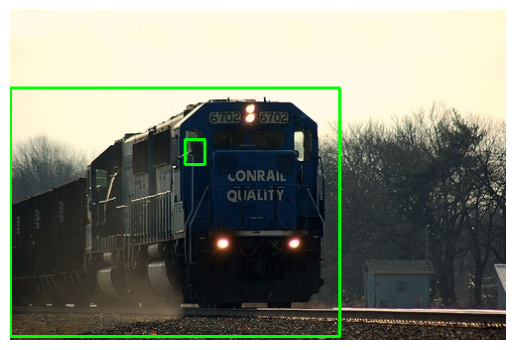

In [125]:
img, _ = test_dataset[0]

with torch.no_grad():
    output = model([transform(img).to(device)])[0]

show_result(img, output)

In [54]:
model.eval()

count = 0

for images, _ in test_loader:
    images = [transform(img).to(device) for img in images]

    with torch.no_grad():
        outputs = model(images)

    print("Detected boxes:", len(outputs[0]["boxes"]))

    count += 1
    if count == 5:
        break

Detected boxes: 6
Detected boxes: 8
Detected boxes: 39
Detected boxes: 5
Detected boxes: 7


In [60]:
import torchvision.transforms as T

transform = T.ToTensor()

model.eval()

all_detections = []

for i, (images, _) in enumerate(test_loader):

    # LIMIT TEST IMAGES (VERY IMPORTANT)
    if i == 20:   # only first 20 images
        break

    # faster batching (no list overhead)
    img = transform(images[0]).to(device)

    with torch.no_grad():
        output = model([img])[0]

    all_detections.append(output)

In [61]:
total_boxes = 0

for det in all_detections:
    total_boxes += len(det["boxes"])

print("Total detections:", total_boxes)
print("Avg detections per image:", total_boxes / len(all_detections))

Total detections: 455
Avg detections per image: 22.75


In [62]:
high_conf_boxes = 0

for det in all_detections:
    scores = det["scores"].cpu()

    high_conf_boxes += (scores > 0.7).sum().item()

print("High confidence detections:", high_conf_boxes)

High confidence detections: 87


In [63]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 72.0 MB/s eta 0:00:00


In [66]:
%%writefile voc.yaml
path: /content/VOCdevkit/VOC2012
train: ImageSets/Main/train.txt
val: ImageSets/Main/val.txt

names:
  0: object

Writing voc.yaml


In [69]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="coco128.yaml",   # built-in working dataset
    epochs=5,
    imgsz=640
)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 11, 13, 14, 15, 16, 17, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 38, 39, 40, 41, 42, 43, 44, 45, 46, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 67, 68, 69, 71, 72, 73, 74, 75, 76, 77, 79])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f822d74fa10>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,

In [90]:
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader
from torch.autograd import Function
import torchvision.transforms as T

In [91]:
class GradReverse(Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.neg() * ctx.alpha, None

In [101]:
transform = T.ToTensor()

def collate_fn(batch):
    batch = [b for b in batch if b is not None]
    return tuple(zip(*batch))

src_dataset = VOCDataset("/content/VOCdevkit/VOC2012/")
tgt_dataset = VOCDataset("/content/VOCdevkit/VOC2007/")

src_loader = DataLoader(src_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
tgt_loader = DataLoader(tgt_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)

In [102]:
class DANN(nn.Module):
    def __init__(self):
        super().__init__()

        self.feature = torchvision.models.resnet18(pretrained=True)
        self.feature.fc = nn.Identity()

        self.classifier = nn.Linear(512, 2)   # object class
        self.domain = nn.Linear(512, 2)       # source vs target

    def forward(self, x, alpha=1.0):
        f = self.feature(x)

        class_out = self.classifier(f)

        rev_f = GradReverse.apply(f, alpha)
        domain_out = self.domain(rev_f)

        return class_out, domain_out

In [103]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DANN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [107]:
import torchvision.transforms as T
import torch
from PIL import ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor()
])

model.train()

for i, ((src_x, src_t), (tgt_x, _)) in enumerate(zip(src_loader, tgt_loader)):

    # -------------------
    # IMAGE PROCESSING
    # -------------------
    src_x = torch.stack([transform(img) for img in src_x]).to(device)
    tgt_x = torch.stack([transform(img) for img in tgt_x]).to(device)

    src_y = torch.ones(len(src_x), dtype=torch.long).to(device)

    # -------------------
    # FORWARD PASS
    # -------------------
    class_out, domain_src = model(src_x, alpha=1.0)
    _, domain_tgt = model(tgt_x, alpha=1.0)

    # -------------------
    # LOSSES
    # -------------------
    loss_class = criterion(class_out, src_y)

    domain_src_y = torch.zeros(len(src_x), dtype=torch.long).to(device)
    domain_tgt_y = torch.ones(len(tgt_x), dtype=torch.long).to(device)

    loss_domain = criterion(domain_src, domain_src_y) + \
                  criterion(domain_tgt, domain_tgt_y)

    loss = loss_class + loss_domain

    # -------------------
    # BACKPROP
    # -------------------
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # PRINT TRAINING PROGRESS
    if i % 5 == 0:
        print(f"Step {i} | Loss: {loss.item():.4f}")

print("DANN Training Done")

Step 0 | Loss: 1.5655
Step 5 | Loss: 1.9766
Step 10 | Loss: 1.7557
Step 15 | Loss: 2.1569
Step 20 | Loss: 2.8297
Step 25 | Loss: 2.4145
Step 30 | Loss: 2.6967
Step 35 | Loss: 2.6511
Step 40 | Loss: 2.6114
Step 45 | Loss: 1.4557
Step 50 | Loss: 1.4384
Step 55 | Loss: 2.0484
Step 60 | Loss: 1.5160
Step 65 | Loss: 1.4896
Step 70 | Loss: 1.6046
Step 75 | Loss: 1.6683
Step 80 | Loss: 1.4052
Step 85 | Loss: 1.4890
Step 90 | Loss: 1.8539
Step 95 | Loss: 1.5263
Step 100 | Loss: 1.7520
Step 105 | Loss: 2.3224
Step 110 | Loss: 2.0058
Step 115 | Loss: 1.6645
Step 120 | Loss: 1.5563
Step 125 | Loss: 1.7918
Step 130 | Loss: 2.0632
Step 135 | Loss: 2.3768
Step 140 | Loss: 2.3349
Step 145 | Loss: 1.9521
Step 150 | Loss: 1.4898
Step 155 | Loss: 1.5662
Step 160 | Loss: 1.7123
Step 165 | Loss: 1.5639
Step 170 | Loss: 1.9700
Step 175 | Loss: 1.8096
Step 180 | Loss: 2.0539
Step 185 | Loss: 2.2470
Step 190 | Loss: 2.0071
Step 195 | Loss: 1.7003
Step 200 | Loss: 3.1957
Step 205 | Loss: 3.3790
Step 210 | Los